## 04_3_Clustering_DBSCAN — 셀별 코드
K-Means에서 Group A(전류 7개)가 최적임을 확인했으므로, DBSCAN은 Group A 고정으로 알고리즘 특성에 집중합니다.

### Cell 1: 라이브러리

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


In [9]:

try:
    import platform
    if platform.system() == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
    else:
        plt.rcParams['font.family'] = 'NanumGothic'
except: pass
plt.rcParams['axes.unicode_minus'] = False

### Cell 2: 데이터 로드 + 전처리

In [10]:
df = pd.read_csv("https://raw.githubusercontent.com/kzming2007/UR3_Cobot_ML/refs/heads/main/dataset/ur3_cobotops.csv")
df_clean = df.dropna().copy()

df_clean['ProtectiveStop_bool'] = df_clean['Robot_ProtectiveStop'].apply(
    lambda x: True if str(x).strip().lower() == 'true' else False
)

# Group A (전류 7개) — K-Means에서 최적으로 선정된 피처 그룹
current_cols = ['Current_J0', 'Current_J1', 'Current_J2',
                'Current_J3', 'Current_J4', 'Current_J5', 'Tool_current']

scaler = StandardScaler()
X = scaler.fit_transform(df_clean[current_cols].values)

print(f"데이터: {X.shape[0]}행 × {X.shape[1]}열 (Group A: 전류 7개)")

데이터: 7355행 × 7열 (Group A: 전류 7개)


#### 1. 파라미터 결정: k-Distance Plot
DBSCAN은 K-Means와 달리 `eps`(이웃 반경)과 `min_samples`(최소 이웃 수) 두 개의 하이퍼파라미터를 사전에 결정해야 한다.
k-Distance Plot은 각 데이터 포인트에서 k번째로 가까운 이웃까지의 거리를 정렬하여 그린 그래프로, 거리가 급격히 증가하는 "무릎(Knee)" 지점이 최적의 eps 후보가 된다.

### Cell 4: k-Distance Plot (eps 결정)

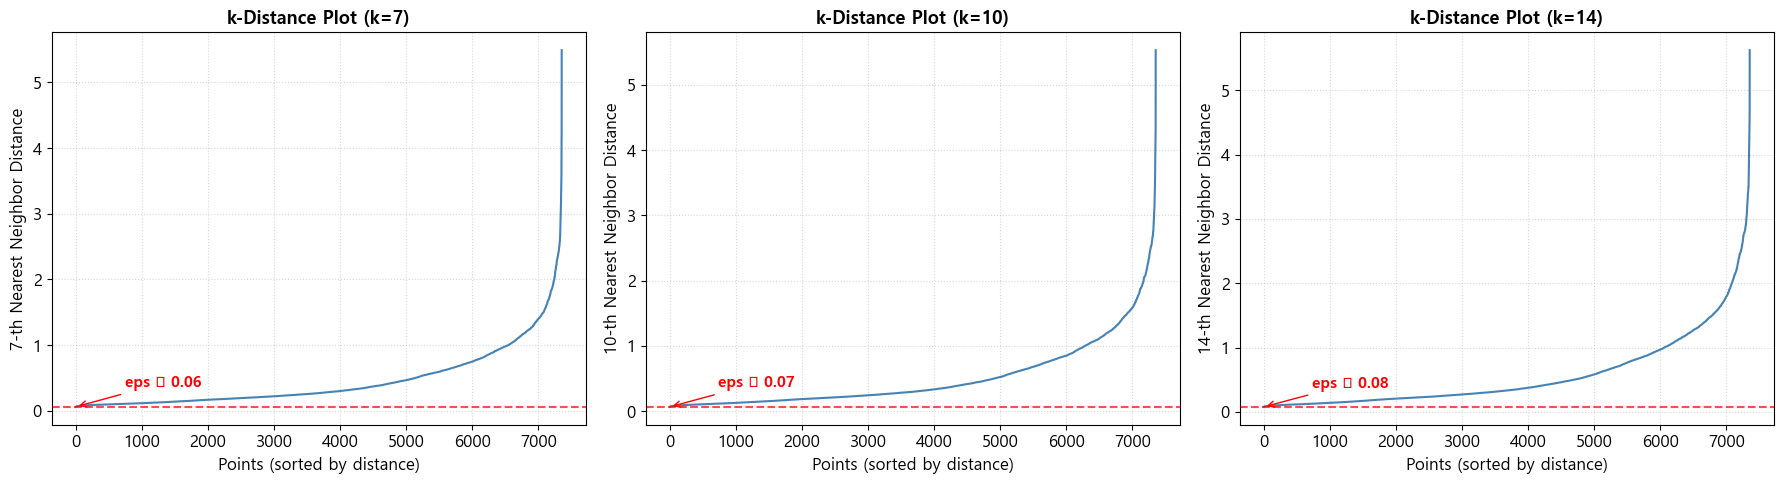

[k-Distance Plot에서 추정된 eps 후보]
  k= 7 → eps ≈ 0.06
  k=10 → eps ≈ 0.07
  k=14 → eps ≈ 0.08


In [11]:
# k-distance plot으로 eps 후보 탐색
# min_samples의 일반적인 권장값: 2 × 차원수 = 2 × 7 = 14
k_values = [7, 10, 14]

fig, axes = plt.subplots(1, len(k_values), figsize=(6 * len(k_values), 5))

eps_candidates = {}
for idx, k in enumerate(k_values):
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X)
    distances, _ = nn.kneighbors(X)
    k_dist = np.sort(distances[:, -1])  # k번째 이웃까지의 거리

    ax = axes[idx]
    ax.plot(range(len(k_dist)), k_dist, linewidth=1.5, color='steelblue')
    ax.set_title(f'k-Distance Plot (k={k})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Points (sorted by distance)')
    ax.set_ylabel(f'{k}-th Nearest Neighbor Distance')
    ax.grid(True, linestyle=':', alpha=0.5)

    # 무릎점(Knee) 자동 추정: 기울기 변화가 가장 큰 지점
    gradient = np.gradient(k_dist)
    knee_idx = np.argmax(gradient > np.percentile(gradient, 95))
    eps_candidates[k] = round(k_dist[knee_idx], 2)

    ax.axhline(y=k_dist[knee_idx], color='red', linestyle='--', alpha=0.7)
    ax.annotate(f'eps ≈ {k_dist[knee_idx]:.2f}',
                xy=(knee_idx, k_dist[knee_idx]),
                xytext=(knee_idx + len(k_dist)*0.1, k_dist[knee_idx] + 0.3),
                fontsize=11, fontweight='bold', color='red',
                arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

print("[k-Distance Plot에서 추정된 eps 후보]")
for k, eps in eps_candidates.items():
    print(f"  k={k:2d} → eps ≈ {eps}")

#### 2. 파라미터 그리드 탐색
k-Distance Plot에서 추정된 eps 후보를 중심으로, eps × min_samples 조합별 군집 수·노이즈 비율·실루엣 스코어를 비교한다.

### Cell 6: eps × min_samples 그리드 탐색

In [12]:
# ⚠️ k-distance plot 결과를 보고 eps_range를 조정하세요
eps_range = np.arange(0.5, 3.1, 0.25)
min_samples_range = [5, 7, 10, 14]

results = []
for eps in eps_range:
    for ms in min_samples_range:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        noise_pct = n_noise / len(labels) * 100

        sil = -1
        if n_clusters >= 2 and n_clusters < len(labels) - n_noise:
            mask = labels != -1
            if len(set(labels[mask])) >= 2:
                sil = silhouette_score(X[mask], labels[mask])

        results.append({
            'eps': round(eps, 2), 'min_samples': ms,
            'n_clusters': n_clusters, 'noise_count': n_noise,
            'noise_pct': round(noise_pct, 1), 'silhouette': round(sil, 4)
        })

df_results = pd.DataFrame(results)

# 유효한 결과만 필터 (군집 2개 이상, 노이즈 50% 미만)
df_valid = df_results[(df_results['n_clusters'] >= 2) &
                       (df_results['noise_pct'] < 50) &
                       (df_results['silhouette'] > 0)].copy()

print(f"[그리드 탐색 결과] 전체 {len(df_results)}개 조합 중 유효: {len(df_valid)}개")
print(f"\n{'='*75}")
print(df_valid.sort_values('silhouette', ascending=False).head(15).to_string(index=False))

# 최적 파라미터
if len(df_valid) > 0:
    best = df_valid.loc[df_valid['silhouette'].idxmax()]
    print(f"\n🏆 최적 파라미터: eps={best['eps']}, min_samples={int(best['min_samples'])}")
    print(f"   → 군집 수={int(best['n_clusters'])}, 노이즈={best['noise_pct']}%, Silhouette={best['silhouette']}")

[그리드 탐색 결과] 전체 44개 조합 중 유효: 35개

 eps  min_samples  n_clusters  noise_count  noise_pct  silhouette
3.00           14           2            4        0.1      0.6984
2.50           14           2           32        0.4      0.6984
2.75           14           2           18        0.2      0.6964
2.00            7           2           57        0.8      0.6938
2.25            7           2           22        0.3      0.6856
2.00           14           3          151        2.1      0.6465
1.75           14           3          199        2.7      0.6449
2.25           14           3           86        1.2      0.6220
2.25            5           2           10        0.1      0.5713
1.50           10           6          208        2.8      0.5623
2.25           10           3           44        0.6      0.5596
2.00            5           3           30        0.4      0.5552
2.00           10           4           79        1.1      0.5338
1.75            7           6           91 

### Cell 7: 그리드 탐색 결과 히트맵

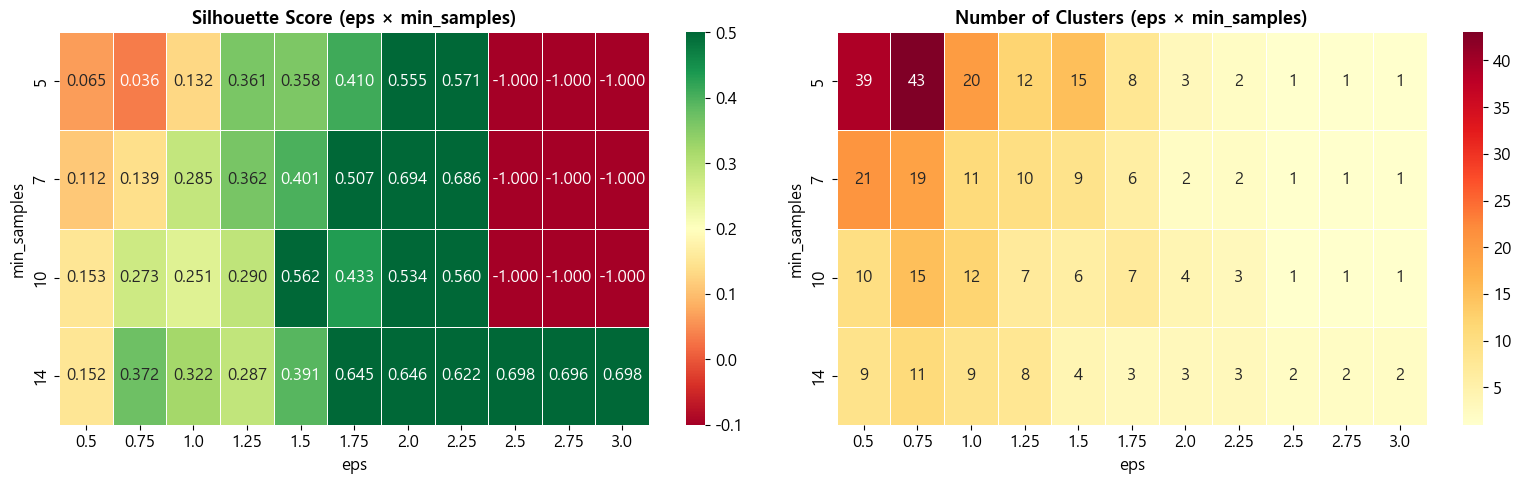

In [13]:
# 실루엣 스코어 히트맵 (eps × min_samples)
pivot_sil = df_results.pivot_table(values='silhouette', index='min_samples',
                                    columns='eps', aggfunc='mean')
pivot_ncl = df_results.pivot_table(values='n_clusters', index='min_samples',
                                    columns='eps', aggfunc='mean')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(pivot_sil, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.5, ax=axes[0], vmin=-0.1, vmax=0.5)
axes[0].set_title('Silhouette Score (eps × min_samples)', fontsize=13, fontweight='bold')

sns.heatmap(pivot_ncl, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Number of Clusters (eps × min_samples)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

#### 3. 최적 DBSCAN 모델 결과
그리드 탐색에서 선정된 최적 파라미터로 DBSCAN을 수행하고, K-Means와 동일한 방식으로 PCA 시각화 및 프로파일링을 진행한다.

### Cell 9: 최적 DBSCAN 학습 + PCA 시각화

[DBSCAN] eps=2, min_samples=10
  군집 수: 4
  노이즈: 79개 (1.1%)
  Silhouette (노이즈 제외): 0.5338


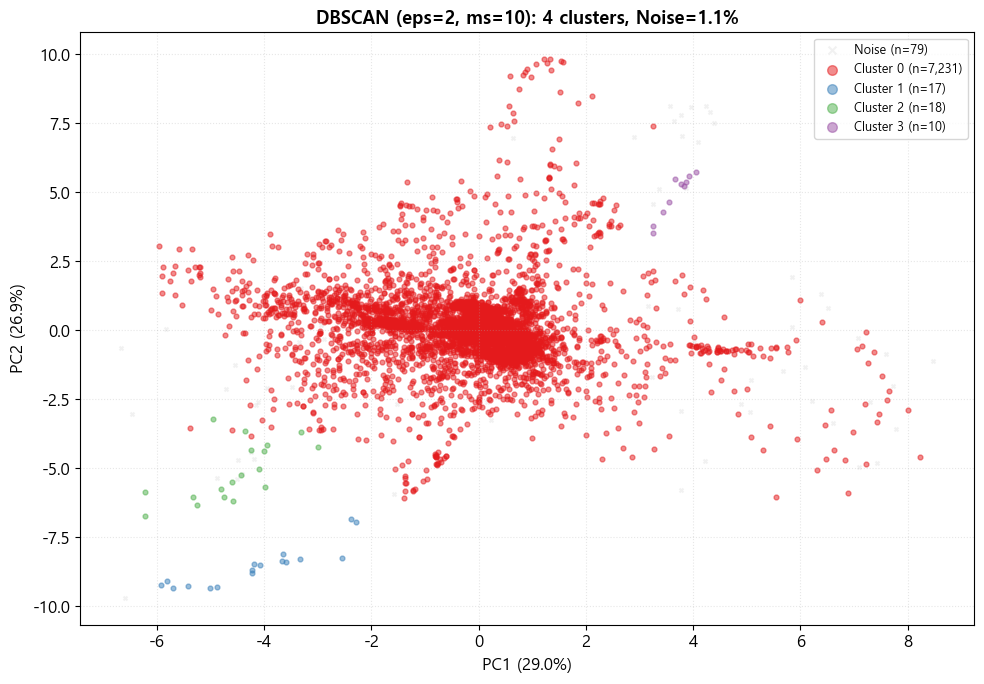

In [22]:
# ⚠️ 그리드 탐색 결과를 보고 최적값을 입력하세요
BEST_EPS = 2#best['eps']         # 예: 1.5
BEST_MS = 10#int(best['min_samples'])  # 예: 10

db_best = DBSCAN(eps=BEST_EPS, min_samples=BEST_MS)
labels_db = db_best.fit_predict(X)

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = (labels_db == -1).sum()
noise_pct = n_noise / len(labels_db) * 100

# 노이즈 제외 실루엣
mask_valid = labels_db != -1
sil_db = silhouette_score(X[mask_valid], labels_db[mask_valid]) if sum(mask_valid) > 0 and len(set(labels_db[mask_valid])) >= 2 else -1

print(f"[DBSCAN] eps={BEST_EPS}, min_samples={BEST_MS}")
print(f"  군집 수: {n_clusters}")
print(f"  노이즈: {n_noise}개 ({noise_pct:.1f}%)")
print(f"  Silhouette (노이즈 제외): {sil_db:.4f}")

# PCA 시각화
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 7))
cmap = plt.cm.Set1

# 노이즈 먼저 (회색으로)
noise_mask = labels_db == -1
if noise_mask.sum() > 0:
    ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
               c='lightgray', alpha=0.3, s=8, marker='x',
               label=f'Noise (n={noise_mask.sum():,})')

# 각 군집
for c_id in sorted(set(labels_db)):
    if c_id == -1:
        continue
    mask = labels_db == c_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[cmap(c_id % 10)], alpha=0.5, s=12,
               label=f'Cluster {c_id} (n={mask.sum():,})')

ax.set_title(f'DBSCAN (eps={BEST_EPS}, ms={BEST_MS}): {n_clusters} clusters, Noise={noise_pct:.1f}%',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=9, markerscale=2, loc='best')
ax.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

### Cell 10: 군집 프로파일링

[DBSCAN] eps=2, min_samples=10 — 군집별 피처 평균
                Current_J0  Current_J1  Current_J2  Current_J3  Current_J4  Current_J5  Tool_current
DBSCAN_Cluster                                                                                      
-1                 -0.1307     -2.0757     -0.8704     -0.1124      0.1333      0.0165        0.2892
 0                 -0.0665     -2.2966     -1.1977     -0.6087     -0.0103      0.0004        0.1077
 1                  5.7767     -3.3036     -1.5961     -1.7099     -3.9409      0.0653        0.0836
 2                  2.8376     -3.0169     -3.1400     -1.5744     -3.3264      0.1057        0.0862
 3                 -2.6477     -2.0515     -0.8566      1.6015      2.2153     -0.0371        0.0848

[군집 크기]
  Cluster -1 (Noise): 79개 (1.1%)
  Cluster 0: 7,231개 (98.3%)
  Cluster 1: 17개 (0.2%)
  Cluster 2: 18개 (0.2%)
  Cluster 3: 10개 (0.1%)


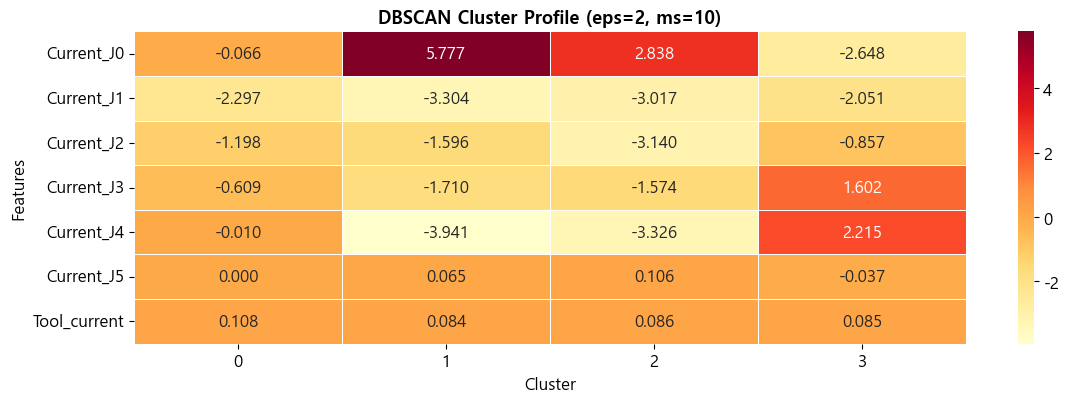

In [23]:
df_clean['DBSCAN_Cluster'] = labels_db

# 군집별 피처 평균 (노이즈 포함)
profile_db = df_clean.groupby('DBSCAN_Cluster')[current_cols].mean()

print(f"{'='*70}")
print(f"[DBSCAN] eps={BEST_EPS}, min_samples={BEST_MS} — 군집별 피처 평균")
print(f"{'='*70}")
print(profile_db.round(4).to_string())

# 군집별 크기
print(f"\n[군집 크기]")
for c_id in sorted(set(labels_db)):
    n = (labels_db == c_id).sum()
    pct = n / len(labels_db) * 100
    tag = " (Noise)" if c_id == -1 else ""
    print(f"  Cluster {c_id}{tag}: {n:,}개 ({pct:.1f}%)")

# 히트맵 (노이즈 제외)
profile_no_noise = profile_db.drop(index=-1, errors='ignore')
fig, ax = plt.subplots(figsize=(12, max(4, len(profile_no_noise) * 0.8 + 1)))
sns.heatmap(profile_no_noise.T, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title(f'DBSCAN Cluster Profile (eps={BEST_EPS}, ms={BEST_MS})',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Features')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

### Cell 11: Silhouette 샘플 분석

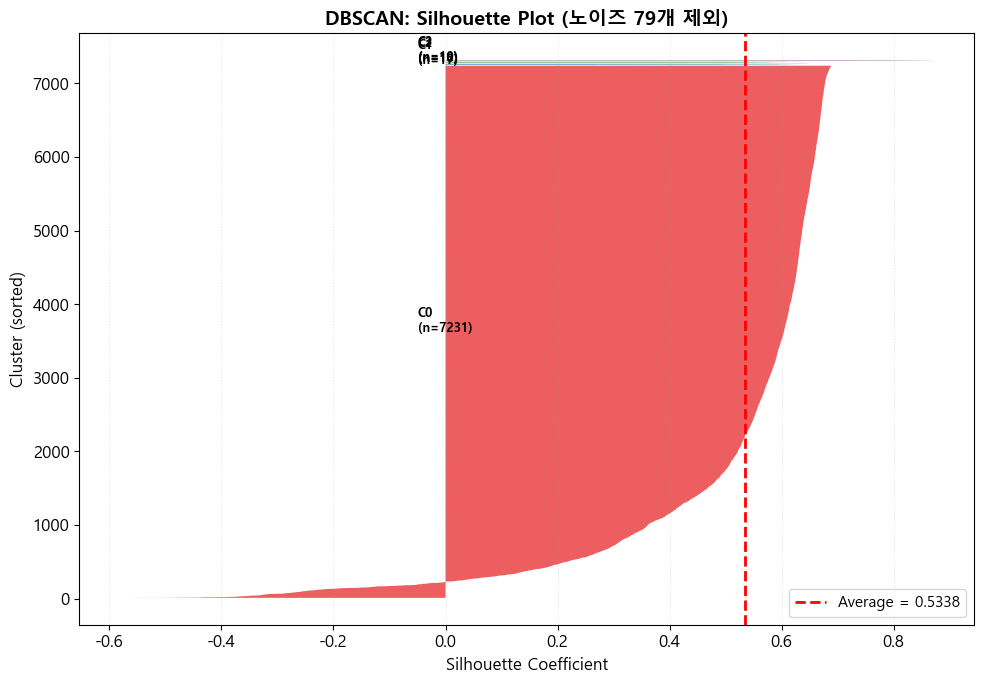

[군집별 Silhouette 통계 (노이즈 제외)]
  Cluster 0: mean=0.5333, min=-0.5812, 음수비율=3.0%
  Cluster 1: mean=0.5523, min=0.2639, 음수비율=0.0%
  Cluster 2: mean=0.5659, min=0.3442, 음수비율=0.0%
  Cluster 3: mean=0.8162, min=0.6881, 음수비율=0.0%


In [24]:
# 노이즈 제외 실루엣
if sil_db > 0:
    sil_samples = silhouette_samples(X[mask_valid], labels_db[mask_valid])
    valid_labels = labels_db[mask_valid]
    unique_clusters = sorted(set(valid_labels))

    fig, ax = plt.subplots(figsize=(10, 7))
    y_lower = 10

    for c_id in unique_clusters:
        cluster_sil = np.sort(sil_samples[valid_labels == c_id])
        size = len(cluster_sil)
        ax.fill_betweenx(np.arange(y_lower, y_lower + size), 0, cluster_sil,
                         facecolor=plt.cm.Set1(c_id % 10), alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size, f'C{c_id}\n(n={size})',
                fontsize=9, fontweight='bold')
        y_lower += size + 10

    ax.axvline(x=sil_db, color='red', linestyle='--', linewidth=2,
               label=f'Average = {sil_db:.4f}')
    ax.set_title(f'DBSCAN: Silhouette Plot (노이즈 {n_noise}개 제외)',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster (sorted)')
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(True, linestyle=':', alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

    print("[군집별 Silhouette 통계 (노이즈 제외)]")
    for c_id in unique_clusters:
        s = sil_samples[valid_labels == c_id]
        neg_pct = (s < 0).sum() / len(s) * 100
        print(f"  Cluster {c_id}: mean={s.mean():.4f}, min={s.min():.4f}, 음수비율={neg_pct:.1f}%")
else:
    print("⚠️ 유효한 군집이 2개 미만이어서 실루엣 분석 불가")

#### 4. K-Means vs DBSCAN 비교
동일한 Group A 피처에 대해 K-Means(K=4)와 DBSCAN의 결과를 직접 비교한다.

### Cell 13: K-Means vs DBSCAN 비교 시각화

   K-Means vs DBSCAN 비교 (Group A)
          Metric K-Means          DBSCAN
            알고리즘 K-Means          DBSCAN
            군집 수       4               4
           노이즈 수       0              79
          노이즈 비율      0%            1.1%
Silhouette Score  0.3814 0.5338 (노이즈 제외)
            파라미터     K=4    eps=2, ms=10


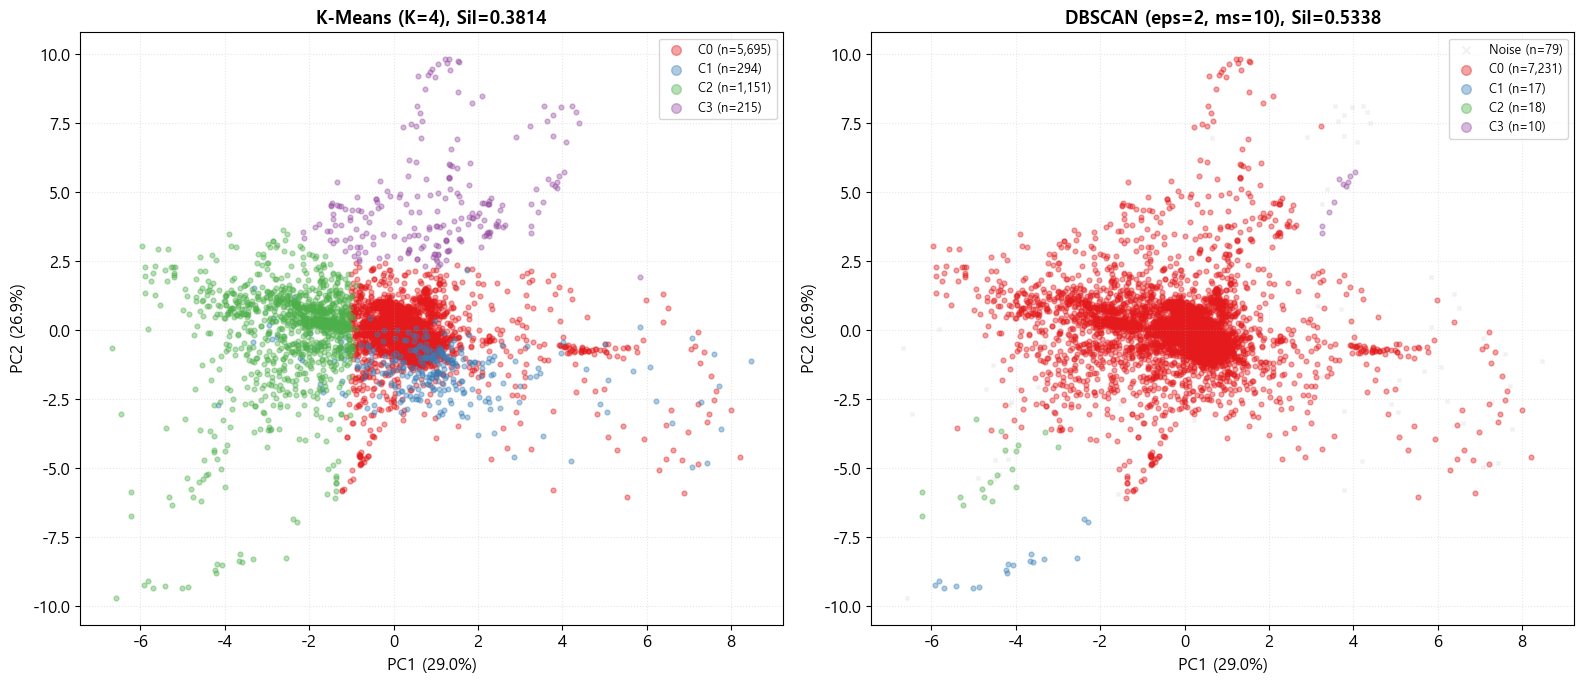

In [25]:
from sklearn.cluster import KMeans

# K-Means 재학습 (비교용)
km = KMeans(n_clusters=4, n_init=10, random_state=42)
labels_km = km.fit_predict(X)
sil_km = silhouette_score(X, labels_km)

# 비교 표
comparison = pd.DataFrame({
    'Metric': ['알고리즘', '군집 수', '노이즈 수', '노이즈 비율',
               'Silhouette Score', '파라미터'],
    'K-Means': ['K-Means', '4', '0', '0%',
                f'{sil_km:.4f}', 'K=4'],
    'DBSCAN': ['DBSCAN', str(n_clusters), str(n_noise), f'{noise_pct:.1f}%',
               f'{sil_db:.4f} (노이즈 제외)', f'eps={BEST_EPS}, ms={BEST_MS}']
})
print("=" * 65)
print("   K-Means vs DBSCAN 비교 (Group A)")
print("=" * 65)
print(comparison.to_string(index=False))

# PCA 나란히 비교
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# K-Means
ax = axes[0]
for c_id in range(4):
    mask = labels_km == c_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[cmap(c_id)], alpha=0.4, s=12,
               label=f'C{c_id} (n={mask.sum():,})')
ax.set_title(f'K-Means (K=4), Sil={sil_km:.4f}', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=9, markerscale=2)
ax.grid(True, linestyle=':', alpha=0.3)

# DBSCAN
ax = axes[1]
if noise_mask.sum() > 0:
    ax.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
               c='lightgray', alpha=0.3, s=8, marker='x',
               label=f'Noise (n={noise_mask.sum():,})')
for c_id in sorted(set(labels_db)):
    if c_id == -1:
        continue
    mask = labels_db == c_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[cmap(c_id % 10)], alpha=0.4, s=12,
               label=f'C{c_id} (n={mask.sum():,})')
ax.set_title(f'DBSCAN (eps={BEST_EPS}, ms={BEST_MS}), Sil={sil_db:.4f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=9, markerscale=2)
ax.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

### Cell 14: 외부 검증 (에러 라벨)

[외부 검증] DBSCAN — 군집별 에러 발생률
   Cluster  Total  Grip Lost (%)  Protective Stop (%)
-1 (Noise)     79           0.00                 8.86
         0   7231           3.35                 3.71
         1     17           5.88                 0.00
         2     18           0.00                16.67
         3     10           0.00                 0.00


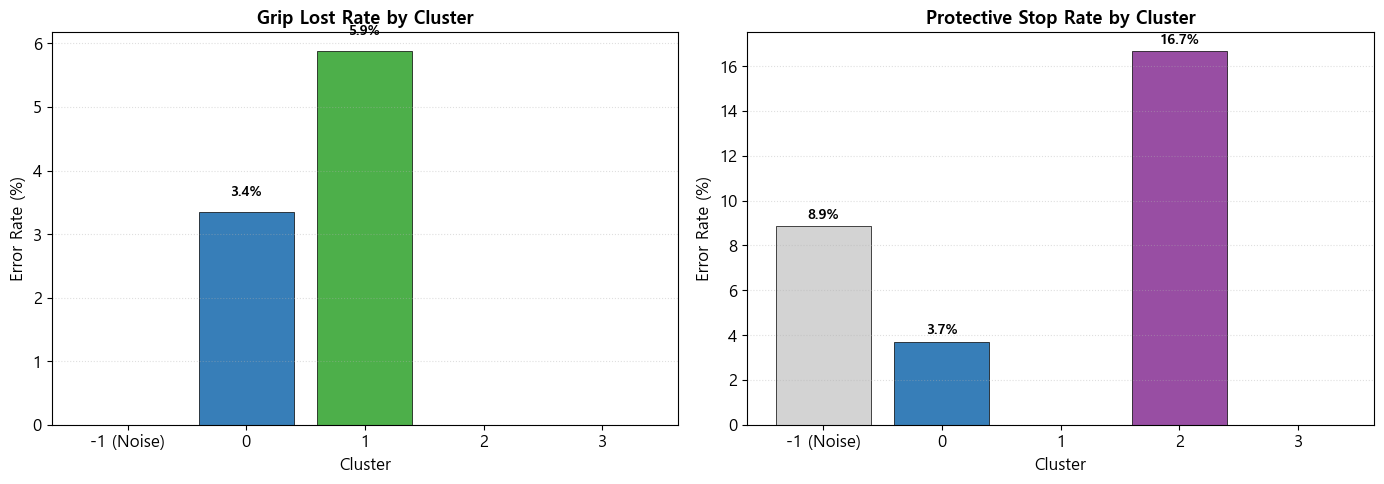


[K-Means ↔ DBSCAN 라벨 일치도]
  ARI = 0.0865
  NMI = 0.0732

[교차표] K-Means Cluster vs DBSCAN Cluster
DBSCAN  -1     0   1   2   3  Total
KMeans                             
0        8  5687   0   0   0   5695
1       39   255   0   0   0    294
2       16  1100  17  18   0   1151
3       16   189   0   0  10    215
Total   79  7231  17  18  10   7355


In [26]:
# 군집별 에러 발생률
best_col = 'DBSCAN_Cluster'

error_rows = []
for c_id in sorted(set(labels_db)):
    subset = df_clean[df_clean[best_col] == c_id]
    n = len(subset)
    tag = " (Noise)" if c_id == -1 else ""
    error_rows.append({
        'Cluster': f'{c_id}{tag}', 'Total': n,
        'Grip Lost (%)': round(subset['grip_lost'].sum() / n * 100, 2),
        'Protective Stop (%)': round(subset['ProtectiveStop_bool'].sum() / n * 100, 2)
    })

df_error = pd.DataFrame(error_rows)
print("=" * 65)
print("[외부 검증] DBSCAN — 군집별 에러 발생률")
print("=" * 65)
print(df_error.to_string(index=False))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_labels = df_error['Cluster'].astype(str)
colors = ['lightgray' if 'Noise' in str(c) else cmap(i % 10)
          for i, c in enumerate(x_labels)]

for idx, (col, title) in enumerate([
    ('Grip Lost (%)', 'Grip Lost Rate by Cluster'),
    ('Protective Stop (%)', 'Protective Stop Rate by Cluster')
]):
    ax = axes[idx]
    bars = ax.bar(x_labels, df_error[col], color=colors,
                  edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, df_error[col]):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                    f'{val:.1f}%', ha='center', va='bottom',
                    fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Error Rate (%)')
    ax.grid(True, linestyle=':', alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

# ARI / NMI (K-Means vs DBSCAN 라벨 일치도)
ari_km_db = adjusted_rand_score(labels_km, labels_db)
nmi_km_db = normalized_mutual_info_score(labels_km, labels_db)

print(f"\n[K-Means ↔ DBSCAN 라벨 일치도]")
print(f"  ARI = {ari_km_db:.4f}")
print(f"  NMI = {nmi_km_db:.4f}")

# 교차표
print(f"\n[교차표] K-Means Cluster vs DBSCAN Cluster")
ct = pd.crosstab(labels_km, labels_db, rownames=['KMeans'], colnames=['DBSCAN'],
                 margins=True, margins_name='Total')
print(ct)

[DBSCAN 추가] eps=2.0, ms=10
  군집 수: 4, 노이즈: 79개 (1.1%)
  Silhouette: 0.5338


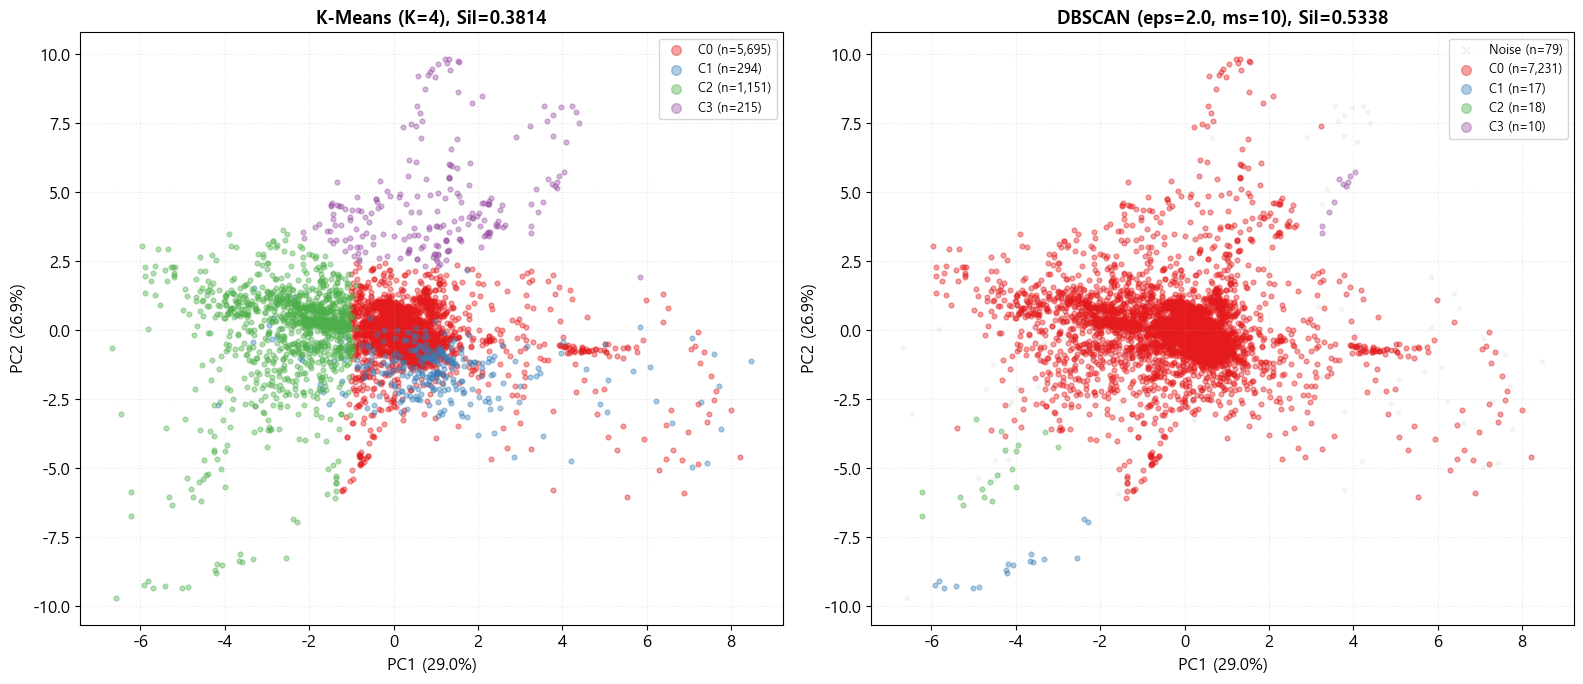

In [19]:
# 군집 수 4개 버전으로 추가 분석
COMPARE_EPS = 2.0
COMPARE_MS = 10

db_compare = DBSCAN(eps=COMPARE_EPS, min_samples=COMPARE_MS)
labels_db4 = db_compare.fit_predict(X)

n_cl4 = len(set(labels_db4)) - (1 if -1 in labels_db4 else 0)
n_noise4 = (labels_db4 == -1).sum()
mask4 = labels_db4 != -1
sil_db4 = silhouette_score(X[mask4], labels_db4[mask4])

print(f"[DBSCAN 추가] eps={COMPARE_EPS}, ms={COMPARE_MS}")
print(f"  군집 수: {n_cl4}, 노이즈: {n_noise4}개 ({n_noise4/len(labels_db4)*100:.1f}%)")
print(f"  Silhouette: {sil_db4:.4f}")

# PCA 비교 (K-Means K=4 vs DBSCAN 4군집)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
for c_id in range(4):
    m = labels_km == c_id
    ax.scatter(X_pca[m, 0], X_pca[m, 1], c=[cmap(c_id)], alpha=0.4, s=12,
               label=f'C{c_id} (n={m.sum():,})')
ax.set_title(f'K-Means (K=4), Sil={sil_km:.4f}', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=9, markerscale=2)
ax.grid(True, linestyle=':', alpha=0.3)

ax = axes[1]
noise4 = labels_db4 == -1
if noise4.sum() > 0:
    ax.scatter(X_pca[noise4, 0], X_pca[noise4, 1],
               c='lightgray', alpha=0.3, s=8, marker='x',
               label=f'Noise (n={noise4.sum():,})')
for c_id in sorted(set(labels_db4)):
    if c_id == -1: continue
    m = labels_db4 == c_id
    ax.scatter(X_pca[m, 0], X_pca[m, 1], c=[cmap(c_id % 10)], alpha=0.4, s=12,
               label=f'C{c_id} (n={m.sum():,})')
ax.set_title(f'DBSCAN (eps={COMPARE_EPS}, ms={COMPARE_MS}), Sil={sil_db4:.4f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=9, markerscale=2)
ax.grid(True, linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()